# PyPSA Network Analysis: Germany 24h

This notebook analyzes the results of a PyPSA simulation for the German power grid, focusing on topology, demand, and generation.

**Scenario Details:**
- **Region:** Germany 
- **Time Period:** A single day (2025-05-14)
- **Resolution:** Hourly snapshots (24 snapshots total)

---
## 1. Setup and Configuration

Commands to build the 470 clusters network from the `germany.yaml` file

```bash
# Build the network 
snakemake --cores 6 "resources/germany/networks/base_s_470_elec_.nc" --configfile config/config.germany.yaml

# Solve the network -> for line loads
snakemake -call solve_elec_networks --configfile config/config.germany.yaml
``

Commands to build the all clusters network without transmission projects from the `germany_base.yaml` file

```bash
# Build the network (dry run)
snakemake -n --cores 6 "resources/germany_base/networks/base_s_all_elec_.nc" --configfile config/config.germany_base.yaml

# Solve the network -> for line loads
snakemake -call solve_elec_networks --configfile config/config.germany_base.yaml
```

### 1.1. Import Libraries

In [2]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs

### 1.2. Load Network Data
Load the solved network model from its `.nc` file.

In [4]:
home = "/home/lucakristin/Desktop/my_pypsa"

#### Network with Transmission Projects (470 Clusters)

In [5]:
config_name_t = "germany"
cluster_t = "470"

# Path to the network file before solving
network_path_unsolved_t = f"{home}/pypsa-eur/resources/{config_name_t}/networks/base_s_{cluster_t}_elec_.nc"

# Path to the network file after solving
network_path_solved_t = f"{home}/pypsa-eur/results/{config_name_t}/networks/base_s_{cluster_t}_elec_.nc"

#### Network without Transmission Projects (450 Clusters)

In [6]:
config_name = "germany_base"
cluster = "450"

# Path to the network file before solving
network_path_unsolved = f"{home}/pypsa-eur/resources/{config_name}/networks/base_s_{cluster}_elec_.nc"

# Path to the network file after solving
network_path_solved = f"{home}/pypsa-eur/results/{config_name}/networks/base_s_{cluster}_elec_.nc"

#### Load the Network to analyze

In [ ]:
# unsolved with projects
network_1 = network_path_unsolved_t

# solved with projects
network_2 = network_path_solved_t

# Caution!! I overwrite this file acidentally with the scenario file!!!
# unsolved without projects
#network_3 = network_path_unsolved

# solved without projects
network_4 = network_path_solved

n = pypsa.Network(network_4, name="Germany Solved Base Network 450")
n_unsolved = pypsa.Network(network_1, name="Germany Unsolved Base Network 470")

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


### Data exploration

In [8]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1350
 - Carrier: 21
 - Generator: 2556
 - Line: 628
 - Link: 1800
 - Load: 450
 - Store: 900
 - SubNetwork: 1
Snapshots: 24

In [9]:
n.generators.carrier.value_counts().to_frame()

,count
carrier,
solar,450
onwind,450
OCGT,402
biomass,401
oil,374
CCGT,248
waste,134
coal,32
offwind-ac,31


#### Input values for the model (before solving step)

In [10]:
# nominal power 
n_unsolved.lines.s_nom.to_frame().head()

,s_nom
name,
0,4379.317262
1,491.556019
10,3396.205223
100,3396.205223
101,1698.102612


In [11]:
# actual summed demand values per bus
n_unsolved.loads_t.p_set.sum().to_frame()

,0
name,
DE0 0,8535.652924
DE0 1,9154.637886
DE0 10,3294.457565
DE0 100,8307.893974
DE0 101,2178.349686
...,...
DE0 95,12416.394791
DE0 96,3137.077316
DE0 97,750.870926


---
## 2. Network Topology and Geographical Visualization

### 2.1. Static Network Plot with Load Distribution
The plot below shows the network buses and lines. The size of each bus corresponds to its electrical load at a specific snapshot, and the line colors distinguish between AC and DC lines.

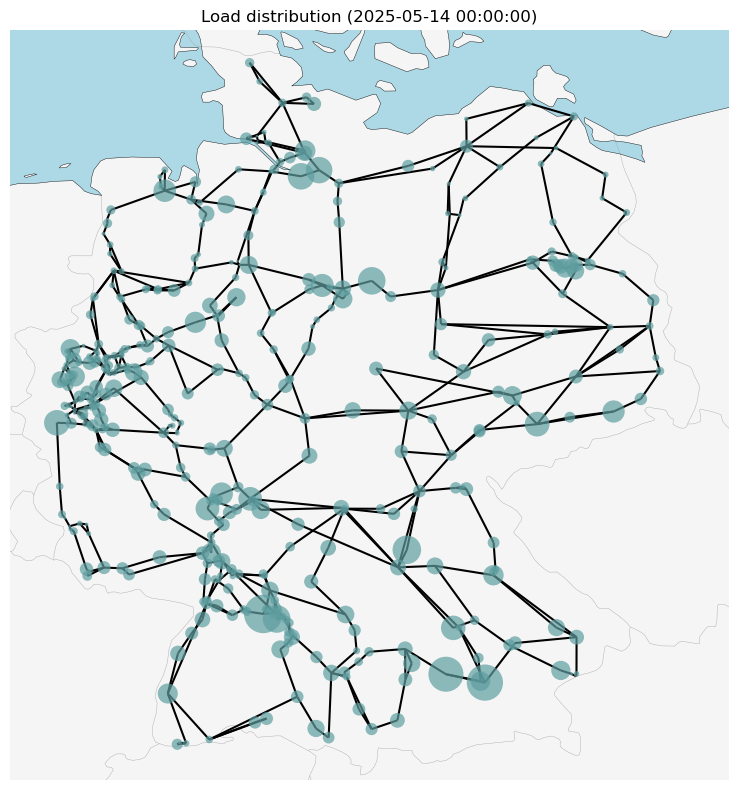

In [12]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

snapshot = n.snapshots[0]
load_distribution = n.loads_t.p_set.loc[snapshot].groupby(n.loads.bus).sum()

n.plot(
    bus_sizes=(load_distribution/20000),
    ax=ax,
    geomap=True,
    bus_alpha=0.7,
    line_colors='black',  # Base color, will be made transparent
    line_alpha=1,  # Make AC lines fully transparent
    link_colors='seagreen',
    link_widths=1,
    title=f"Load distribution ({snapshot})",
    geomap_color=True
);


plt.tight_layout()
plt.show()

### 2.2 Lines 
The Line components represent power transmission and distribution lines. They connect a bus0 to a bus1. They can connect to buses with carrier "AC" or "DC". Power flow through lines is not directly controllable, but is determined passively by their impedances and the nodal power imbalances according to Kirchhoff's voltage law. To see how the impedances are used in the power flow, see the line model.

https://docs.pypsa.org/latest/user-guide/components/lines/

In [13]:

print("AC Line voltage levels and their counts:")
# This shows the different nominal voltages for AC lines, which are used for coloring
display(n.lines.v_nom.value_counts().to_frame("Count"))

AC Line voltage levels and their counts:


,Count
v_nom,
380.0,628


### Base network from osm

https://pypsa-eur.readthedocs.io/en/latest/base-network-raw.html

[image-2.png](attachment:image-2.png)

In [14]:
display(n.lines.head())

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,v_nom,i_nom,dc
name,,,,,,,,,,,,,,,,,,,,,
0,DE0 0,DE0 243,Al/St 240/40 4-bundle 380.0,17.078117,2.082697,0.0,0.000301,1698.102612,0.0,True,...,0.000118,1.442311e-05,0.0,0.0,0.000118,1.442311e-05,1698.102739,380.0,2.58,False
1,DE0 0,DE0 329,Al/St 240/40 4-bundle 380.0,10.683821,1.302905,0.0,0.000753,3396.205223,0.0,True,...,0.000074,9.022887e-06,0.0,0.0,0.000074,9.022887e-06,3396.205322,380.0,2.58,False
10,DE0 1,DE0 150,Al/St 240/40 4-bundle 380.0,8.123010,0.990611,0.0,0.000573,3396.205223,0.0,True,...,0.000056,6.860187e-06,0.0,0.0,0.000056,6.860187e-06,3396.205639,380.0,2.58,False
100,DE0 130,DE0 153,Al/St 240/40 4-bundle 380.0,3.852334,0.469797,0.0,0.000272,3396.205223,0.0,True,...,0.000027,3.253441e-06,0.0,0.0,0.000027,3.253441e-06,3396.205505,380.0,2.58,False
101,DE0 130,DE0 347,Al/St 240/40 4-bundle 380.0,0.221092,0.026962,0.0,0.000016,3396.205223,0.0,True,...,0.000002,1.867201e-07,0.0,0.0,0.000002,1.867201e-07,3396.210245,380.0,2.58,False


In [15]:
# Count lines with a build year before 2025
len(n.lines[n.lines.build_year < 2025])

628

In [16]:
# Count lines with a build year before 2025
len(n.lines[n.lines.build_year > 2025])

0

### 2.3 Links 
The Link components are used for controllable directed flows between two or more buses with arbitrary energy carriers (bus0, bus1, bus2, etc.). For instance, they can represent point-to-point HVDC links, unidirectional lossy HVDC links, converters between AC and DC, net transfer capacities (NTCs) of HVAC lines (neglecting Kirchhoff's voltage law), as well as any conversion between carriers (e.g. electricity to hydrogen in electrolysis, electricity to heat in heat pumps, or gas to electricity and heat in a combined heat and power (CHP) plant).


- The Link component has one dispatch variable p0 associated with the input from bus0 (positive if withdrawing from bus0) and one or more outputs p1, p2, etc. associated with the output at bus1, bus2, etc. (negative if supplying to these buses). The outputs at bus1, bus2, etc. are proportional to the input at bus0 multiplied by the corresponding efficiency (e.g. efficiency, efficiency2, etc.). That means that the link can have multiple outputs in fixed ratio to the input.

- The columns bus2, efficiency2, bus3, efficiency3, etc. in n.links are automatically added to the component attributes.

- Any marginal_cost are related to the input p0 at bus0 (e.g. cost per unit of fuel consumed rather than cost per unit of electricity produced for a power plant).

- For links with multiple inputs in fixed ratio to one of the inputs, you can define the other inputs as outputs with a negative efficiency so that they withdraw from the corresponding bus if there is a positive flow for p0.

- For delayed energy transport, use the attribute delay, delay2, ... which postpones the output at bus1, bus2, ... in terms of elapsed time, taking snapshot weightings into account. See this example.

https://docs.pypsa.org/latest/user-guide/components/links/


In [17]:
links_now = n.links[(n.links.build_year < 2025)]
len(links_now)

1800

In [18]:
links_future = n.links[(n.links.build_year > 2025)]
len(links_future)

0

In [19]:
links_future

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,reversed
name,,,,,,,,,,,,,,,,,,,,,


In [20]:
links_future[['p_nom_opt', 'build_year', 'carrier']]

,p_nom_opt,build_year,carrier
name,,,


In [21]:
links_by_groups = links_now.groupby("carrier").sum()
links_by_groups

,bus0,bus1,type,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,reversed
carrier,,,,,,,,,,,,,,,,,,,,,
H2 Electrolysis,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,,314.730000,450,0,11250.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,0.171370,0
H2 Fuel Cell,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,225.000000,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,0.084570,0
battery charger,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,965.245010,0
battery discharger,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,985.149063,0


In [22]:
carriers_to_plot  = links_by_groups.index.tolist()
carriers_to_plot

['H2 Electrolysis', 'H2 Fuel Cell', 'battery charger', 'battery discharger']

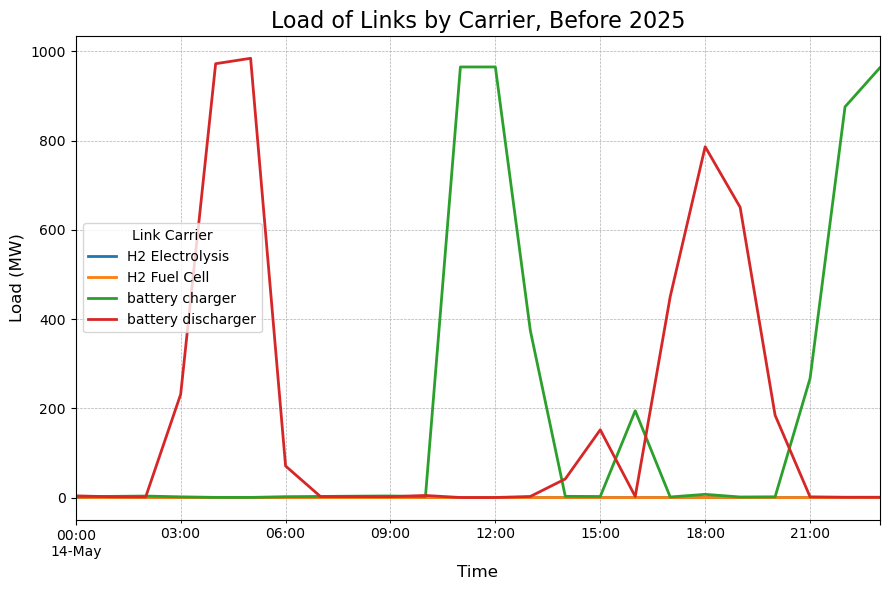

In [23]:
# Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(9, 6))

# Plot the load for each carrier
for carrier in carriers_to_plot:
    link_loads = n.links_t.p0.abs()  # Absolute load on links at each snapshot

    # Find the links associated with the current carrier
    carrier_links = n.links[(n.links.carrier == carrier) & (n.links.build_year < 2025) ].index
    
    # Sum the loads of these links at each snapshot
    total_load_per_snapshot = link_loads[carrier_links].sum(axis=1)
    
    # Plot the total load for the carrier
    total_load_per_snapshot.plot(ax=ax, label=carrier, lw=2)

# Set plot titles and labels
ax.set_title("Load of Links by Carrier, Before 2025", fontsize=16)
ax.set_ylabel("Load (MW)", fontsize=12)
ax.set_xlabel("Time", fontsize=12)

# Add a legend to identify the lines
ax.legend(title="Link Carrier", fontsize=10)

# Add a grid for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Ensure the layout is tight
plt.tight_layout()

# Show the plot
plt.show()

In [24]:
display(links_by_groups)

,bus0,bus1,type,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,reversed
carrier,,,,,,,,,,,,,,,,,,,,,
H2 Electrolysis,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,,314.730000,450,0,11250.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,0.171370,0
H2 Fuel Cell,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,225.000000,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,0.084570,0
battery charger,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,965.245010,0
battery discharger,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,985.149063,0


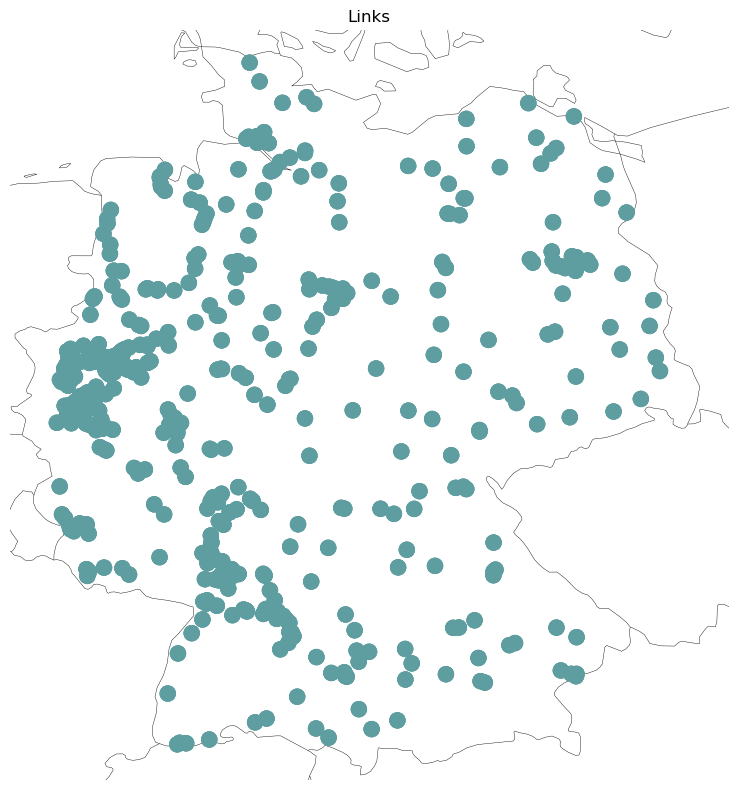

In [25]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

# To plot only DC links, we make the AC lines transparent.
n.plot(
    ax=ax,
    geomap=True,
    bus_sizes=0.01,
    line_colors='black',  # Base color, will be made transparent
    line_alpha=0.0,  # Make AC lines fully transparent
    link_colors='seagreen',
    link_widths=2.0,
    title="Links"
);

plt.tight_layout()
plt.show()

### 2.4. Detailed Map
CURRENTLY NOT WORKING: This plot shows the energy balance at each bus using pie charts. The size of the pie chart represents the total energy, and the slices show the contribution of different carriers (generation, load, storage).

Line loading is the ratio of the power flowing through a line to its nominal capacity. This plot shows the loading for a specific snapshot.

1.  **`loading`**: This variable represents the loading of each transmission line as a ratio. It's calculated as `n.lines_t.p0 / n.lines.s_nom`, which is the actual power flow on the line divided by the line's maximum capacity.

2.  **Direction of Flow**: Power flow (`p0`) in PyPSA has a direction. It can be positive or negative depending on whether power is flowing from `bus0` to `bus1` or vice-versa. Consequently, the `loading` variable can have negative values (e.g., -0.7, meaning 70% of capacity is used, but in the reverse direction).

3.  **`.abs()`**: This is the absolute value function. When you call `.abs()`, it converts all the negative loading values to positive ones. For example, a loading of `-0.7` becomes `0.7`.

Line loading statistics for snapshot 2025-05-14 09:00:00:


count    628.000000
mean       0.003585
std        0.327024
min       -1.318875
25%       -0.174953
50%        0.008650
75%        0.193600
max        1.064328
dtype: float64

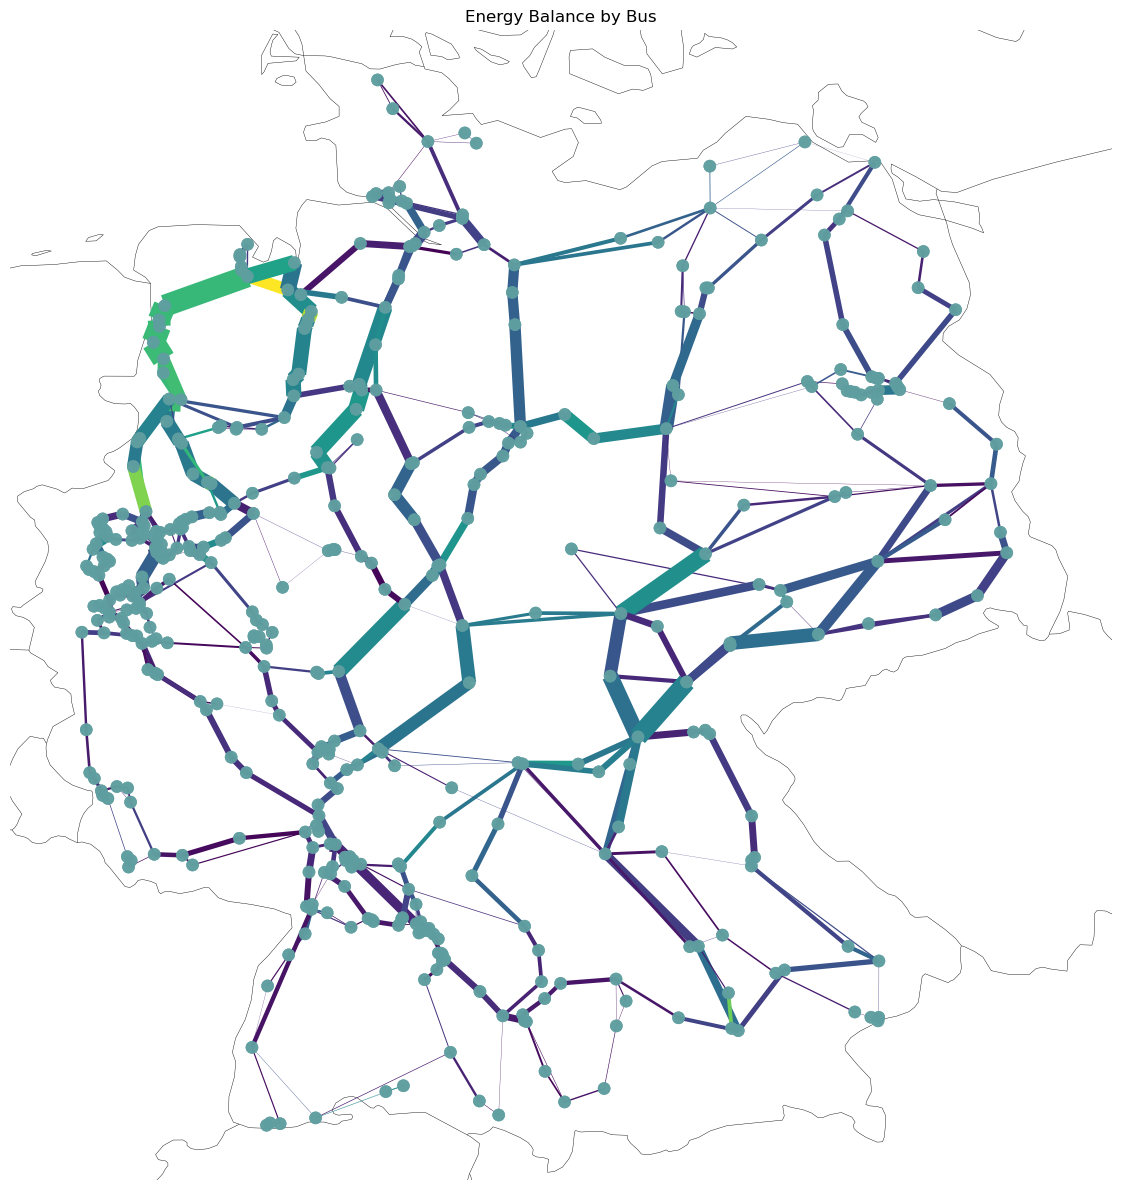

In [26]:
# Calculate energy balance for pie charts
eb = (
    n.statistics.energy_balance(
        groupby=["bus", "carrier"],
        components=["Generator", "Load", "StorageUnit"],
    )
    .groupby(["bus", "carrier"])
    .sum()
)

# Define colors for carriers
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "orange", "oil": "gray", "ror": "turquoise", "geothermal": "red",
    "Load": "darkred", # Color for load
}
n.carriers.color = n.carriers.index.map(colors)
n.carriers.loc["", "color"] = "darkred"
n.carriers.loc["-", "color"] = "darkred"

# Calculate total flow for line/link widths
line_flow = n.lines_t.p0.sum(axis=0)
link_flow = n.links_t.p0.sum(axis=0)



bus_size_factor = 1e9
branch_width_factor = 4000

# Create a new figure for this plot
fig, ax = plt.subplots(
    1, 1, figsize=(12, 12),
    subplot_kw={"projection": ccrs.EqualEarth()}
)
# Select a snapshot to analyze
now = n.snapshots[9]
loading = n.lines_t.p0.loc[now] / n.lines.s_nom
print(f"Line loading statistics for snapshot {now}:")
display(loading.describe())

n.plot(
    ax=ax,
    geomap=True,
    line_colors=loading.abs(),
    bus_sizes=eb.abs().sum() / bus_size_factor,
    bus_alpha=0.7,
    bus_split_circle=True,
    line_width=line_flow / branch_width_factor,
    link_width=link_flow / branch_width_factor,
    title="Energy Balance by Bus"
)
plt.tight_layout()
plt.show()


plt.show()

---
## 3. Demand (Load) Analysis
This section explores the electricity demand across the network, from high-level summaries to detailed time-series profiles.

### 3.1. Top Buses by Annual Load
A summary of the buses with the highest total electricity consumption over the simulation period.

In [27]:
if not n.loads.empty and hasattr(n.loads_t, "p_set") and not n.loads_t.p_set.empty:
    annual_load_by_bus = n.loads_t.p_set.sum().sort_values(ascending=False)
    print("\nTop buses by annual load [MWh over snapshots]:")
    display(annual_load_by_bus.head(15).to_frame("load_MWh"))


Top buses by annual load [MWh over snapshots]:


,load_MWh
name,
DE0 27,32583.887917
DE0 184,28919.592667
DE0 26,27030.198746
DE0 93,17928.510147
DE0 84,16935.742897
DE0 48,16732.389969
DE0 97,15524.390602
DE0 4,15435.780960
DE0 36,14382.988503


### 3.2. Total Load Over Simulation Period
The total aggregated load for the entire network over all snapshots.

In [28]:
# Total load over the simulation period
loads = n.loads_t.p_set.sum().to_frame("total_load_MWh") #sum over all snapshots
print("Total load summary:")
loads

Total load summary:


,total_load_MWh
name,
DE0 0,5667.703224
DE0 1,2986.133942
DE0 10,5105.844742
DE0 100,54.414322
DE0 101,6778.602821
...,...
DE0 95,1683.301643
DE0 96,7283.174644
DE0 97,15524.390602


### 3.3. Load Profile for Multiple Buses
This plot shows the electricity demand (load) over the 24-hour period for the first five buses in the network.

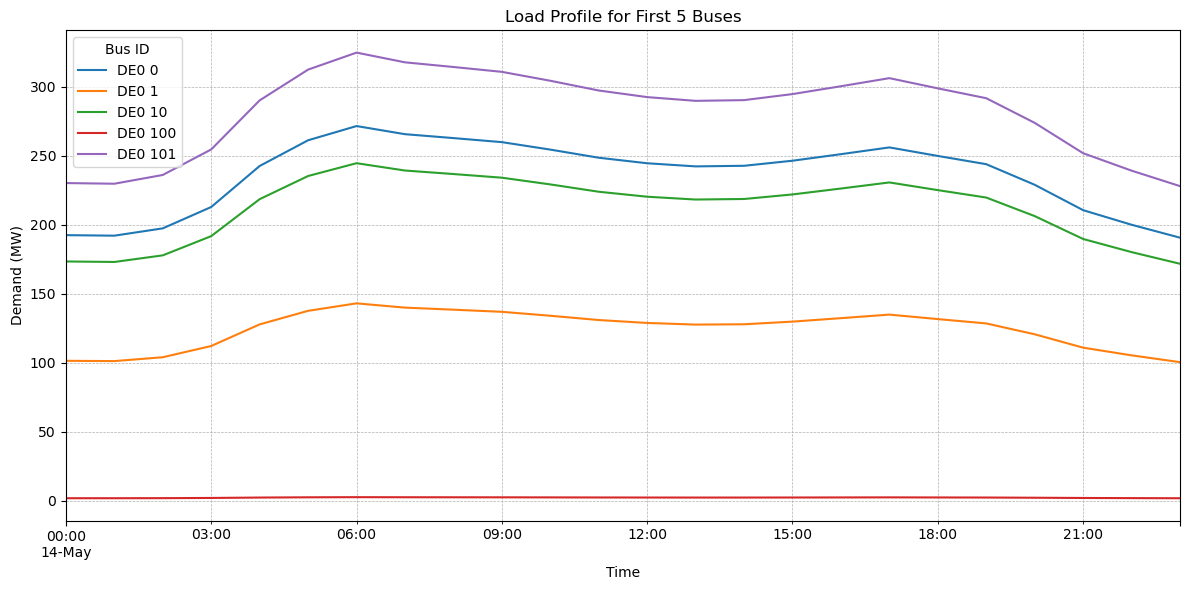

In [29]:
# --- Plot load for multiple buses ---

# Choose buses to inspect (e.g., the first 5)
buses_to_plot = n.buses.index[:5]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

for bus in buses_to_plot:
    # Find all loads connected to this bus
    loads_on_bus = n.loads[n.loads.bus == bus].index
    
    # Get the time-series data for these loads and sum them up
    if not loads_on_bus.empty:
        load_profile = n.loads_t.p_set[loads_on_bus].sum(axis=1)
        load_profile.plot(ax=ax, label=bus)

ax.set_title("Load Profile for First 5 Buses")
ax.set_ylabel("Demand (MW)")
ax.set_xlabel("Time")
ax.legend(title="Bus ID")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 4. Generation Analysis
This section visualizes the generation side of the network, including installed capacities, dispatch patterns, and curtailment.

### 4.1. Installed Capacity Analysis
An overview of the installed generation capacity, grouped by carrier type and by bus.

In [30]:
if not n.generators.empty:
    cap_by_carrier = n.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False)
    print("Installed generator capacity by carrier [MW]:")
    display(cap_by_carrier.head(20).to_frame("p_nom_MW"))

    cap_by_bus = n.generators.groupby("bus")["p_nom"].sum().sort_values(ascending=False)
    print("\nTop buses by installed generation capacity [MW]:")
    display(cap_by_bus.head(15).to_frame("p_nom_MW"))

Installed generator capacity by carrier [MW]:


,p_nom_MW
carrier,
onwind,73332.065900
solar,48771.254020
CCGT,24626.502664
coal,16281.556000
lignite,15565.628000
offwind-ac,13396.491600
biomass,8020.001833
OCGT,6112.743723
oil,4547.476789



Top buses by installed generation capacity [MW]:


,p_nom_MW
bus,
DE0 250,11860.715463
DE0 192,6059.111397
DE0 155,3699.873690
DE0 36,3462.455092
DE0 257,3438.591030
DE0 2,3310.205807
DE0 61,2927.040401
DE0 32,2682.268965
DE0 412,2560.565424


### 4.2. Renewables: Average Generator Availability per Carrier
The following plots show the average `p_max_pu` (per unit maximum availability) for all generators of a specific carrier type. This is particularly relevant for renewable sources like wind and solar.

In [31]:
# Get all unique carriers
carriers = n.generators.carrier.unique()
print(carriers)

['OCGT' 'biomass' 'oil' 'waste' 'CCGT' 'lignite' 'coal' 'geothermal'
 'offwind-ac' 'solar' 'onwind' 'offwind-dc']


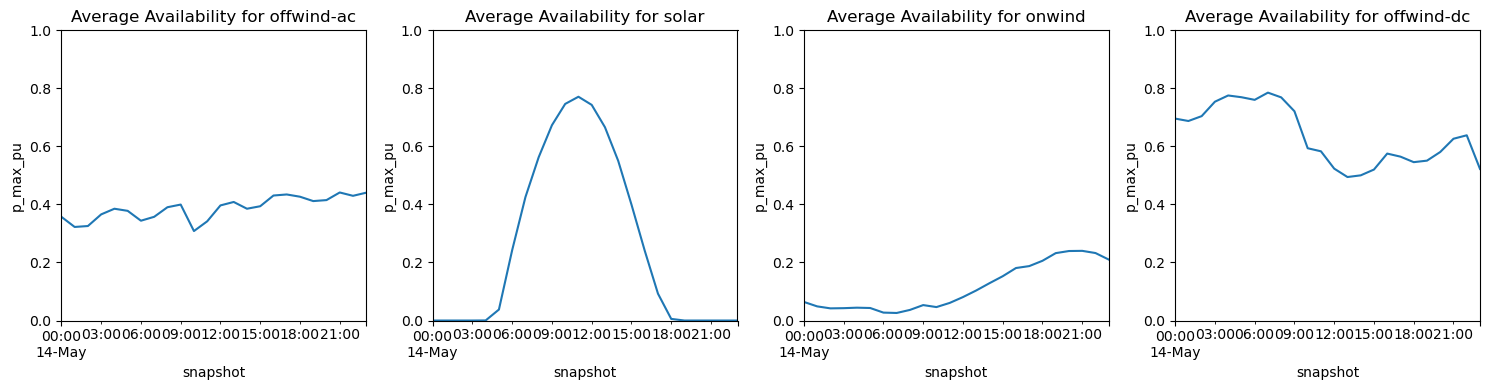

In [32]:
# Get all unique carriers
carriers = ['offwind-ac','solar','onwind','offwind-dc']

# Create a figure with subplots for each carrier
n_carriers = len(carriers)
n_cols = 4
n_rows = (n_carriers + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, carrier in enumerate(carriers):
    ax = axes[i]
    
    # Find all generators for the current carrier
    gens_for_carrier = n.generators.index[n.generators.carrier == carrier]
    
    # Find the intersection of generators for the carrier and columns in p_max_pu
    common_gens = n.generators_t.p_max_pu.columns.intersection(gens_for_carrier)
    
    # Plot the AVERAGE p_max_pu for these generators
    if not common_gens.empty:
        p_max_pu_carrier = n.generators_t.p_max_pu[common_gens]
        p_max_pu_carrier.mean(axis=1).plot(ax=ax, legend=False)
    
    ax.set_title(f"Average Availability for {carrier}")
    ax.set_ylabel("p_max_pu")
    ax.set_ylim(0, 1)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.3. Power Dispatch by Carrier
This stacked area plot shows the total power generated (dispatched) by each major carrier type over time.

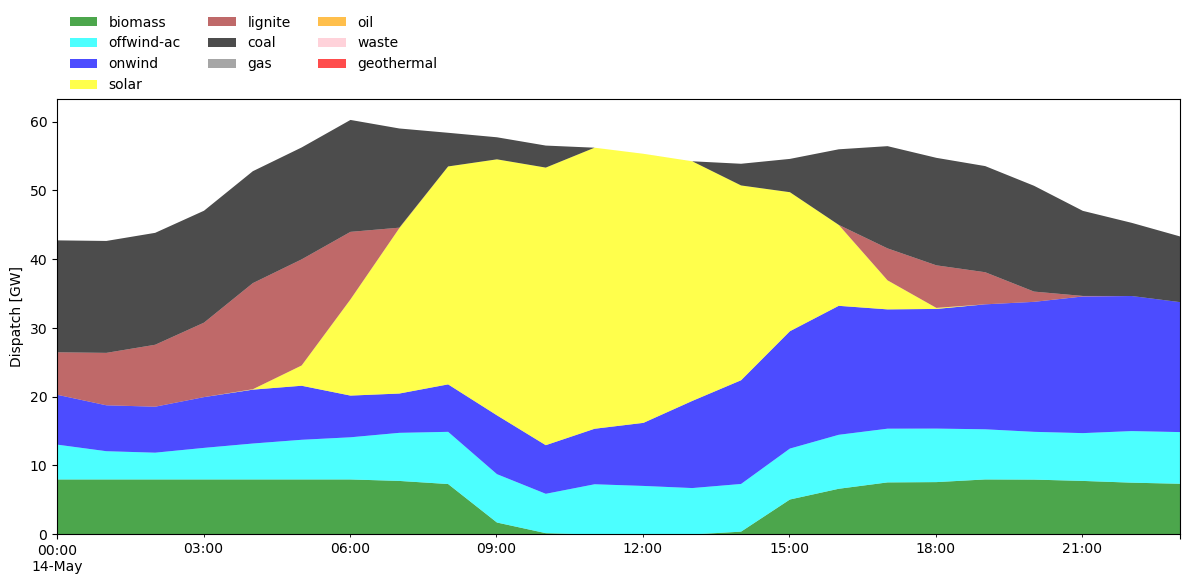

In [33]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
# Drop carriers with very low production for clarity
to_drop = p_by_carrier.max()[p_by_carrier.max() < 1700].index
p_by_carrier.drop(to_drop, axis=1, inplace=True)

# Define colors and order for the dispatch plot
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "gray", "oil": "orange", "waste": "pink", "geothermal": "red",
}


# Reorder columns for a conventional stack
cols = [
    "biomass", "offwind-ac", "onwind", "solar", "lignite", "coal", "gas", "oil", "waste", "geothermal"
]
p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

c = [colors.get(col, "gray") for col in p_by_carrier.columns]
fig, ax = plt.subplots(figsize=(12, 6))
p_by_carrier.div(1e3).plot(kind="area", ax=ax, lw=0, color=c, alpha=0.7)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, 1.02, 1, 0.2), frameon=False)
ax.set_ylabel("Dispatch [GW]")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 4.4. Curtailment Analysis
Curtailment is the reduction in the output of a generator from what it could otherwise produce. Here we calculate and plot it for the 'onwind' carrier as an example.

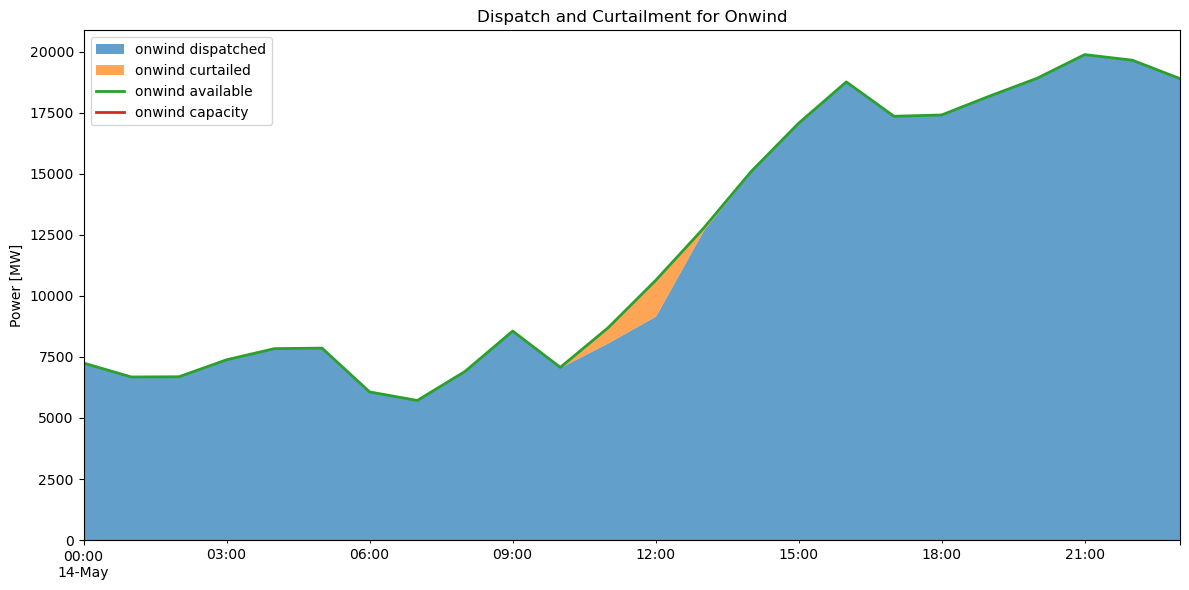

In [34]:
carrier = "onwind"

capacity = n.generators.groupby("carrier").sum().at[carrier, "p_nom"]
p_available = n.generators_t.p_max_pu.multiply(n.generators["p_nom"])
p_available_by_carrier = p_available.T.groupby(n.generators.carrier).sum().T
p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

p_df = pd.DataFrame(
    {
        carrier + " available": p_available_by_carrier[carrier],
        carrier + " dispatched": p_by_carrier[carrier],
        carrier + " curtailed": p_curtailed_by_carrier[carrier],
    }
)

p_df[carrier + " capacity"] = capacity

# Correct for any minor negative values from floating point inaccuracies
p_df.loc[p_df[f"{carrier} curtailed"] < 0, f"{carrier} curtailed"] = 0

fig, ax = plt.subplots(figsize=(12, 6))
p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0, alpha=0.7)
p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax, lw=2)

ax.set_xlabel("")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Dispatch and Curtailment for {carrier.title()}")
ax.legend()
plt.tight_layout()
plt.show()

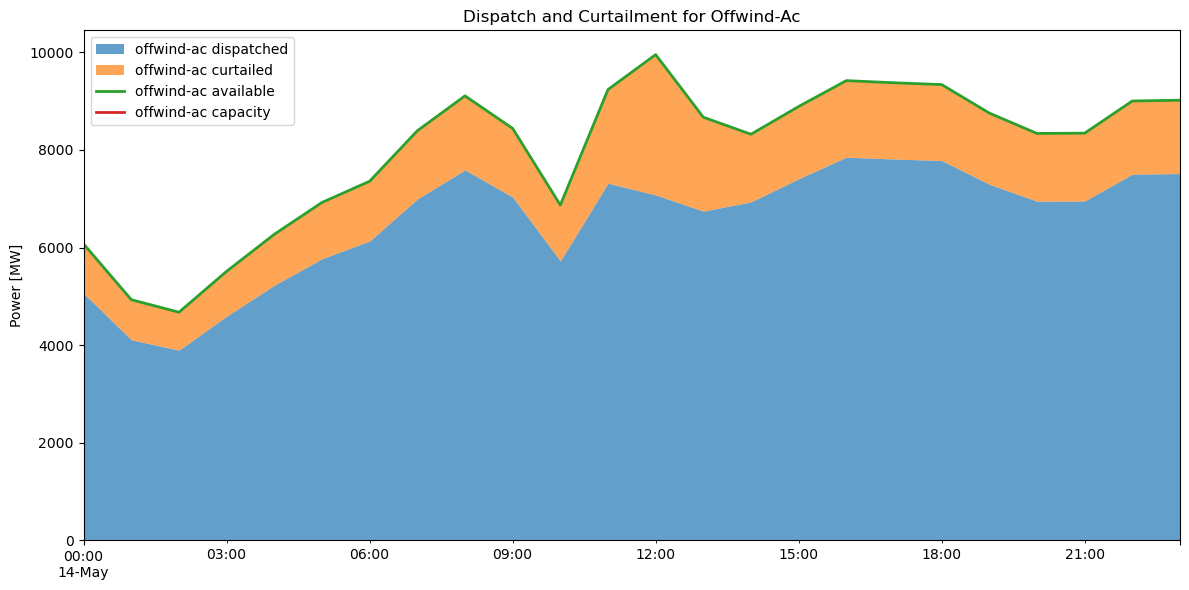

In [38]:
carrier = "offwind-ac"

capacity = n.generators.groupby("carrier").sum().at[carrier, "p_nom"]
p_available = n.generators_t.p_max_pu.multiply(n.generators["p_nom"])
p_available_by_carrier = p_available.T.groupby(n.generators.carrier).sum().T
p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

p_df = pd.DataFrame(
    {
        carrier + " available": p_available_by_carrier[carrier],
        carrier + " dispatched": p_by_carrier[carrier],
        carrier + " curtailed": p_curtailed_by_carrier[carrier],
    }
)

p_df[carrier + " capacity"] = capacity

# Correct for any minor negative values from floating point inaccuracies
p_df.loc[p_df[f"{carrier} curtailed"] < 0, f"{carrier} curtailed"] = 0

fig, ax = plt.subplots(figsize=(12, 6))
p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0, alpha=0.7)
p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax, lw=2)

ax.set_xlabel("")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Dispatch and Curtailment for {carrier.title()}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Grid and Transmission Analysis
This final section focuses on the state of the transmission grid itself.

### 5.1. Line Length Statistics
A statistical summary of the lengths of the transmission lines in the network.

In [35]:
if not n.lines.empty:
    print("\nLine length statistics [km]:")
    if "length" in n.lines.columns:
        display(n.lines["length"].describe().to_frame("value"))
    else:
        print("No 'length' column in n.lines")


Line length statistics [km]:


,value
count,628.000000
mean,24.147808
std,23.506236
min,1.043104
25%,6.667175
50%,15.446361
75%,35.789595
max,154.940177


### Interesting for IFISC Model
- buses: IDs and coordinates,
- lines: `bus0`, `bus1`, `x` (reactance), `r` (resistance), `s_nom` (nominal power), `length`,
- generators: `bus`, `carrier` (type of energy source e.g. solar, gas), `p_nom` (nominal power),
- loads: `bus`, `p_set` (active power setpoint),
- time series: `generators_t.p` (dispatch), `loads_t.p_set` (active power demand), `buses_t.v_ang` (voltage phase angle)

- Reactance
    - electrical property that impedes changes in current and is crucial for calculating AC power flow. It's a primary factor in determining how power is distributed across parallel paths.
- Resistance 
    - electrical resistance of the line. This causes real power losses (dissipated as heat) as electricity flows through it.
- Nominal power
    - maximum rated active power output of the generator in MW (Megawatts). This is its installed capacity.
- Active Power Setpoint
    - static value representing the profile of the load. It's a multiplier that is combined with the time series data to get the actual demand at any given time.
- Dispatch: (result of the simulation) 
    - showing how much power each generator is actually producing at a given time (in MW).
- active power demand (input)
    - time-varying active power demand for each load at each snapshot (in MW)
- Voltage phase angle (result)
    - The voltage phase angle for each bus at each snapshot (in radians)
    - Power naturally flows from a bus with a leading (higher) phase angle to a bus with a lagging (lower) phase angle -> larger phase angle difference results in a larger amount of power being transferred.

In [36]:
#calculated voltage phase angle for every bus in your network at every time snapshot
phase_angles = n.buses_t.v_ang
phase_angles.head()


name,DE0 0,DE0 1,DE0 10,DE0 100,DE0 101,DE0 102,DE0 103,DE0 104,DE0 105,DE0 106,...,DE0 90 battery,DE0 91 battery,DE0 92 battery,DE0 93 battery,DE0 94 battery,DE0 95 battery,DE0 96 battery,DE0 97 battery,DE0 98 battery,DE0 99 battery
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,-0.208885,-0.013112,-0.015966,0.248721,-0.068765,-0.018196,-0.267560,0.148731,-0.106744,-0.332490,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-14 01:00:00,-0.189204,-0.013920,-0.034460,0.285137,-0.083502,0.017664,-0.263003,0.112422,-0.113718,-0.323071,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-14 02:00:00,-0.199790,-0.014080,-0.025812,0.292994,-0.068112,0.015632,-0.278031,0.106560,-0.108965,-0.340523,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-14 03:00:00,-0.239791,-0.013150,-0.003592,0.300556,-0.041507,-0.007355,-0.327950,0.134523,-0.106796,-0.397022,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-14 04:00:00,-0.287341,-0.016815,0.050353,0.266933,0.033746,-0.047814,-0.387423,0.157302,-0.078298,-0.468555,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
generation = n.generators_t.p
generation.head()

name,DE0 0 OCGT,DE0 0 biomass,DE0 0 oil,DE0 0 waste,DE0 1 OCGT,DE0 1 biomass,DE0 1 oil,DE0 10 CCGT,DE0 10 OCGT,DE0 10 biomass,...,DE0 95 0 onwind,DE0 96 0 onwind,DE0 97 0 onwind,DE0 98 0 onwind,DE0 99 0 onwind,DE0 132 0 offwind-dc,DE0 192 0 offwind-dc,DE0 238 0 offwind-dc,DE0 250 0 offwind-dc,DE0 42 0 offwind-dc
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,0.000089,153.657364,0.000031,0.000323,0.000089,27.373364,0.000031,0.000163,0.000089,3.352367,...,0.000019,-0.0,16.292989,3.634746,2.666100,0.000110,0.000153,0.000074,0.000052,0.000125
2025-05-14 01:00:00,0.000089,153.657365,0.000031,0.000323,0.000089,27.373365,0.000031,0.000163,0.000089,3.352367,...,0.000011,-0.0,13.136638,-0.000000,2.061358,0.000100,0.000159,0.000068,0.000058,0.000122
2025-05-14 02:00:00,0.000090,153.657412,0.000031,0.000337,0.000090,27.373412,0.000031,0.000167,0.000090,3.352414,...,0.000007,-0.0,11.333740,-0.000000,1.512123,0.000103,0.000162,0.000067,0.000066,0.000123
2025-05-14 03:00:00,0.000098,153.657604,0.000031,0.000468,0.000097,27.373597,0.000031,0.000192,0.000097,3.352600,...,0.000006,-0.0,13.141528,-0.000000,-0.000000,0.000112,0.000166,0.000082,0.000084,0.000127
2025-05-14 04:00:00,0.000119,153.657765,0.000033,0.019055,0.000118,27.373758,0.000033,0.000296,0.000118,3.352758,...,0.000009,-0.0,16.563185,-0.000000,-0.000000,0.000106,0.000172,0.000099,0.000103,0.000130


In [169]:
demand = n.loads_t.p_set
demand.head()

name,DE0 0,DE0 1,DE0 10,DE0 100,DE0 101,DE0 102,DE0 103,DE0 104,DE0 105,DE0 106,...,DE0 90,DE0 91,DE0 92,DE0 93,DE0 94,DE0 95,DE0 96,DE0 97,DE0 98,DE0 99
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,192.449104,101.395355,173.370979,1.847656,230.170135,132.593788,119.591835,122.863205,67.294212,67.898270,...,127.943901,136.832703,184.012428,608.769646,117.151497,57.157173,247.303078,527.136818,421.603592,228.390976
2025-05-14 01:00:00,192.055130,101.187790,173.016060,1.843880,229.698944,132.322350,119.347015,122.611679,67.156456,67.759270,...,127.681976,136.552582,183.635727,607.523399,116.911674,57.040161,246.796806,526.057686,420.740509,227.923424
2025-05-14 02:00:00,197.359009,103.982231,177.794151,1.894798,236.042412,135.976624,122.642952,125.997780,69.011078,69.630539,...,131.208099,140.323685,188.707092,624.301041,120.140358,58.615410,253.612457,540.585533,432.359863,234.217857
2025-05-14 03:00:00,212.830788,112.133827,191.732155,2.043343,254.546745,146.636383,132.257439,135.875259,74.421135,75.089165,...,141.494041,151.324226,203.500610,673.242554,129.558655,63.210510,273.494171,582.964241,466.254318,252.579155
2025-05-14 04:00:00,242.548180,127.790985,218.503563,2.328651,290.088898,167.111099,150.724434,154.847412,84.812500,85.573799,...,161.250740,172.453506,231.915237,767.246864,147.648819,72.036545,311.681946,664.363068,531.357033,287.846573


## Scigrid

INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x7e449827cf50>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x7e449827d090>,
  'Transformer': <matplotlib.collections.LineCollection at 0x7e449827d1d0>},
 'flows': {}}

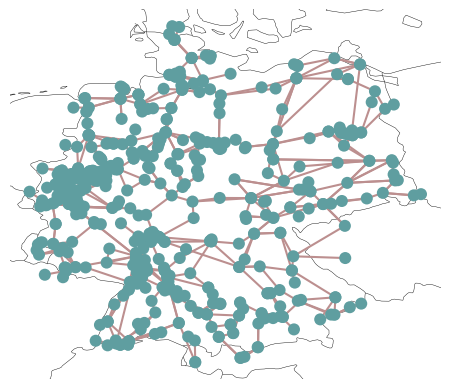

In [170]:
n_scigrid = pypsa.examples.scigrid_de()
n_scigrid.plot()
    

In [171]:
n_scigrid.lines.head()

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,ref,cables,x_ohmkm,wires,osm_name,operator,c_nfkm,frequency,length_m,i_th_max_a
name,,,,,,,,,,,,,,,,,,,,,
1,1,2_220kV,Al/St 240/40 2-bundle 220.0,0.0,0.0,0.0,0.0,495.366531,0.0,False,...,2016,3.0,0.320,2.0,Leitung 2016,TenneT,11.5,50.0,43379.0,1.3
2,3,4,Al/St 240/40 4-bundle 380.0,0.0,0.0,0.0,0.0,3422.532396,0.0,False,...,,6.0,0.125,4.0,Leitung 3011,TenneT,27.4,50.0,72686.0,5.2
3,5_220kV,6,Al/St 240/40 2-bundle 220.0,0.0,0.0,0.0,0.0,990.733062,0.0,False,...,1,6.0,0.160,2.0,Leitung 2024,TenneT,23.0,50.0,33943.0,2.6
4,7,5,Al/St 240/40 4-bundle 380.0,0.0,0.0,0.0,0.0,1711.266198,0.0,False,...,3026,3.0,0.250,4.0,Leitung 3026,TenneT,13.7,50.0,33471.0,2.6
5,8,9,Al/St 240/40 4-bundle 380.0,0.0,0.0,0.0,0.0,3422.532396,0.0,False,...,,6.0,0.125,4.0,KKW Krümmel - UW Lüneburg,transpower,27.4,50.0,28163.0,5.2


In [172]:
n_scigrid.links.head()


attribute,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
